In [1]:
!pip install -q transformers datasets accelerate scikit-learn pandas matplotlib sentencepiece

In [ ]:
import torch
import transformers

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("GPU:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

In [3]:
from google.colab import files

uploaded = files.upload()

Saving test_data.csv to test_data.csv
Saving training_data.csv to training_data (1).csv


In [4]:
import os

print(os.listdir("/content"))

['.config', 'training_data.csv', 'test_data.csv', 'training_data (1).csv', 'sample_data']


In [5]:
import pandas as pd
import numpy as np

TRAIN_PATH = "/content/training_data.csv"
TEST_PATH = "/content/test_data.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# training_Set.csv의 BOM 문자 제거
train_df.columns = [
    column.replace("\ufeff", "").strip()
    for column in train_df.columns
]

test_df.columns = [
    column.replace("\ufeff", "").strip()
    for column in test_df.columns
]

print("train:", train_df.shape)
print("test:", test_df.shape)
print("train columns:", train_df.columns.tolist())
print("test columns:", test_df.columns.tolist())

train: (20000, 6)
test: (1467, 6)
train columns: ['text', 'label', 'menu', 'temperature', 'quantity', 'memo']
test columns: ['text', 'label', 'menu', 'temperature', 'quantity', 'memo']


In [7]:
def normalize_dataset(df):
    df = df.copy()

    df["text"] = (
        df["text"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    df["label"] = (
        df["label"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df["menu"] = (
        df["menu"]
        .fillna("NONE")
        .astype(str)
        .str.strip()
    )

    df["temperature"] = (
        df["temperature"]
        .fillna("NONE")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # 온도 라벨 통일
    temperature_map = {
        "COLD": "ICE",
        "ICED": "ICE",
        "차가운": "ICE",
        "따뜻한": "HOT",
        "WARM": "HOT",
        "": "NONE",
        "NAN": "NONE",
    }

    df["temperature"] = df["temperature"].replace(temperature_map)

    def normalize_quantity(value):
        if pd.isna(value):
            return "NONE"

        value = str(value).strip()

        if value == "" or value.lower() == "nan":
            return "NONE"

        try:
            number = float(value)

            if number.is_integer():
                return str(int(number))
        except ValueError:
            pass

        return value

    df["quantity"] = df["quantity"].apply(normalize_quantity)

    for column in ["menu", "temperature", "quantity"]:
        df[column] = df[column].replace(
            {
                "": "NONE",
                "nan": "NONE",
                "NaN": "NONE",
                "NAN": "NONE",
            }
        )

    # 빈 문장/라벨 제거
    df = df[
        (df["text"] != "")
        & (df["label"] != "")
    ].copy()

    # 완전히 같은 데이터 제거
    df = df.drop_duplicates(
        subset=[
            "text",
            "label",
            "menu",
            "temperature",
            "quantity",
        ]
    ).reset_index(drop=True)

    return df


train_df = normalize_dataset(train_df)
test_df = normalize_dataset(test_df)

print("정리 후 train:", train_df.shape)
print("정리 후 test:", test_df.shape)

정리 후 train: (19983, 6)
정리 후 test: (1467, 6)


In [6]:
test_texts = set(test_df["text"])

overlap_mask = train_df["text"].isin(test_texts)

print("train-test 중복 문장 수:", overlap_mask.sum())

train_df = train_df[~overlap_mask].reset_index(drop=True)

print("중복 제거 후 train:", len(train_df))

train-test 중복 문장 수: 16
중복 제거 후 train: 19984


In [8]:
invalid_order_menu = (
    (train_df["label"] == "ORDER")
    & (train_df["menu"] == "NONE")
)

print("ORDER인데 menu가 없는 데이터:", invalid_order_menu.sum())

display(
    train_df.loc[
        invalid_order_menu,
        ["text", "label", "menu", "temperature", "quantity"]
    ]
)

ORDER인데 menu가 없는 데이터: 7


,text,label,menu,temperature,quantity
10019,샷 하나 추가해주세요,ORDER,NONE,NONE,1
10028,이거 하나 주세요,ORDER,NONE,NONE,1
10036,매장에서 먹고 갈게요,ORDER,NONE,NONE,NONE
10171,휘핑크림 올려주세요,ORDER,NONE,NONE,NONE
10183,얼음 적게 넣어 주세요,ORDER,NONE,ICE,NONE
10199,음료 주문할게요,ORDER,NONE,NONE,NONE
10225,따뜻하게 한 잔 주세요,ORDER,NONE,HOT,1


In [9]:
train_df = train_df[~invalid_order_menu].reset_index(drop=True)

print("최종 train 크기:", train_df.shape)

최종 train 크기: (19976, 6)


In [10]:
from sklearn.model_selection import train_test_split

SEED = 42

train_split, valid_split = train_test_split(
    train_df,
    test_size=0.15,
    random_state=SEED,
    stratify=train_df["label"],
)

train_split = train_split.reset_index(drop=True)
valid_split = valid_split.reset_index(drop=True)
test_split = test_df.reset_index(drop=True)

print("train:", len(train_split))
print("valid:", len(valid_split))
print("test:", len(test_split))

train: 16979
valid: 2997
test: 1467


In [11]:
from sklearn.preprocessing import LabelEncoder

INTENT_COLUMN = "label"
SLOT_COLUMNS = ["menu", "temperature", "quantity"]

intent_encoder = LabelEncoder()
menu_encoder = LabelEncoder()
temperature_encoder = LabelEncoder()
quantity_encoder = LabelEncoder()

intent_encoder.fit(train_split["label"])

order_train = train_split[
    train_split["label"] == "ORDER"
].copy()

menu_encoder.fit(order_train["menu"])
temperature_encoder.fit(order_train["temperature"])
quantity_encoder.fit(order_train["quantity"])

print("intent:", intent_encoder.classes_)
print("menu:", menu_encoder.classes_)
print("temperature:", temperature_encoder.classes_)
print("quantity:", quantity_encoder.classes_)

intent: ['AFFIRM' 'CANCEL' 'DENY' 'GUIDE' 'MODIFY' 'ORDER' 'PAYMENT' 'UNKNOWN']
menu: ['딸기스무디' '레몬에이드' '바닐라라떼' '아메리카노' '카페라떼']
temperature: ['HOT' 'ICE' 'NONE']
quantity: ['1' '2' '3' 'NONE']


In [12]:
def find_unseen_values(train_encoder, values):
    known = set(train_encoder.classes_)
    actual = set(values)

    return sorted(actual - known)


test_order = test_split[
    test_split["label"] == "ORDER"
]

print(
    "unseen intent:",
    find_unseen_values(intent_encoder, test_split["label"])
)

print(
    "unseen menu:",
    find_unseen_values(menu_encoder, test_order["menu"])
)

print(
    "unseen temperature:",
    find_unseen_values(
        temperature_encoder,
        test_order["temperature"]
    )
)

print(
    "unseen quantity:",
    find_unseen_values(
        quantity_encoder,
        test_order["quantity"]
    )
)

unseen intent: []
unseen menu: []
unseen temperature: []
unseen quantity: []


In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

MODEL_NAME = "monologg/koelectra-small-v3-discriminator"
MAX_LENGTH = 64
IGNORE_INDEX = -100

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False,
)


class MultiTaskNLUDataset(Dataset):
    def __init__(
        self,
        dataframe,
        tokenizer,
        intent_encoder,
        menu_encoder,
        temperature_encoder,
        quantity_encoder,
        max_length=64,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.intent_encoder = intent_encoder
        self.menu_encoder = menu_encoder
        self.temperature_encoder = temperature_encoder
        self.quantity_encoder = quantity_encoder
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        encoded = self.tokenizer(
            row["text"],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        intent_id = int(
            self.intent_encoder.transform([row["label"]])[0]
        )

        is_order = row["label"] == "ORDER"

        if is_order:
            menu_id = int(
                self.menu_encoder.transform([row["menu"]])[0]
            )

            temperature_id = int(
                self.temperature_encoder.transform(
                    [row["temperature"]]
                )[0]
            )

            quantity_id = int(
                self.quantity_encoder.transform(
                    [row["quantity"]]
                )[0]
            )
        else:
            # ORDER가 아니면 slot loss를 무시
            menu_id = IGNORE_INDEX
            temperature_id = IGNORE_INDEX
            quantity_id = IGNORE_INDEX

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "intent_labels": torch.tensor(intent_id),
            "menu_labels": torch.tensor(menu_id),
            "temperature_labels": torch.tensor(temperature_id),
            "quantity_labels": torch.tensor(quantity_id),
            "text": row["text"],
        }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/263k [00:00<?, ?B/s]

In [14]:
train_dataset = MultiTaskNLUDataset(
    train_split,
    tokenizer,
    intent_encoder,
    menu_encoder,
    temperature_encoder,
    quantity_encoder,
    MAX_LENGTH,
)

valid_dataset = MultiTaskNLUDataset(
    valid_split,
    tokenizer,
    intent_encoder,
    menu_encoder,
    temperature_encoder,
    quantity_encoder,
    MAX_LENGTH,
)

test_dataset = MultiTaskNLUDataset(
    test_split,
    tokenizer,
    intent_encoder,
    menu_encoder,
    temperature_encoder,
    quantity_encoder,
    MAX_LENGTH,
)

print(len(train_dataset), len(valid_dataset), len(test_dataset))

16979 2997 1467


In [15]:
import torch.nn as nn
from transformers import AutoModel


class MultiTaskKoELECTRA(nn.Module):
    def __init__(
        self,
        model_name,
        num_intents,
        num_menus,
        num_temperatures,
        num_quantities,
        dropout=0.1,
    ):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)

        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)

        self.intent_head = nn.Linear(
            hidden_size,
            num_intents,
        )

        self.menu_head = nn.Linear(
            hidden_size,
            num_menus,
        )

        self.temperature_head = nn.Linear(
            hidden_size,
            num_temperatures,
        )

        self.quantity_head = nn.Linear(
            hidden_size,
            num_quantities,
        )

        self.loss_fn = nn.CrossEntropyLoss(
            ignore_index=IGNORE_INDEX
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        intent_labels=None,
        menu_labels=None,
        temperature_labels=None,
        quantity_labels=None,
    ):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        # ELECTRA의 첫 토큰([CLS]) 표현 사용
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)

        intent_logits = self.intent_head(cls_output)
        menu_logits = self.menu_head(cls_output)
        temperature_logits = self.temperature_head(cls_output)
        quantity_logits = self.quantity_head(cls_output)

        total_loss = None
        losses = {}

        if intent_labels is not None:
            intent_loss = self.loss_fn(
                intent_logits,
                intent_labels,
            )

            menu_loss = self.loss_fn(
                menu_logits,
                menu_labels,
            )

            temperature_loss = self.loss_fn(
                temperature_logits,
                temperature_labels,
            )

            quantity_loss = self.loss_fn(
                quantity_logits,
                quantity_labels,
            )

            total_loss = (
                intent_loss
                + menu_loss
                + temperature_loss
                + quantity_loss
            )

            losses = {
                "intent_loss": intent_loss,
                "menu_loss": menu_loss,
                "temperature_loss": temperature_loss,
                "quantity_loss": quantity_loss,
            }

        return {
            "loss": total_loss,
            "losses": losses,
            "intent_logits": intent_logits,
            "menu_logits": menu_logits,
            "temperature_logits": temperature_logits,
            "quantity_logits": quantity_logits,
        }

In [16]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = MultiTaskKoELECTRA(
    model_name=MODEL_NAME,
    num_intents=len(intent_encoder.classes_),
    num_menus=len(menu_encoder.classes_),
    num_temperatures=len(temperature_encoder.classes_),
    num_quantities=len(quantity_encoder.classes_),
).to(device)

print(device)

pytorch_model.bin:   0%|          | 0.00/56.6M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] ElectraModel LOAD REPORT from: monologg/koelectra-small-v3-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/56.5M [00:00<?, ?B/s]

cuda


In [17]:
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.01

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [18]:
from transformers import get_linear_schedule_with_warmup

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.1)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

In [19]:
from sklearn.metrics import accuracy_score, f1_score


def evaluate_model(model, data_loader):
    model.eval()

    total_loss = 0.0

    true_intents = []
    pred_intents = []

    true_menus = []
    pred_menus = []

    true_temperatures = []
    pred_temperatures = []

    true_quantities = []
    pred_quantities = []

    frame_results = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            intent_labels = batch["intent_labels"].to(device)
            menu_labels = batch["menu_labels"].to(device)
            temperature_labels = batch["temperature_labels"].to(device)
            quantity_labels = batch["quantity_labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                intent_labels=intent_labels,
                menu_labels=menu_labels,
                temperature_labels=temperature_labels,
                quantity_labels=quantity_labels,
            )

            total_loss += outputs["loss"].item()

            intent_preds = outputs[
                "intent_logits"
            ].argmax(dim=-1)

            menu_preds = outputs[
                "menu_logits"
            ].argmax(dim=-1)

            temperature_preds = outputs[
                "temperature_logits"
            ].argmax(dim=-1)

            quantity_preds = outputs[
                "quantity_logits"
            ].argmax(dim=-1)

            true_intents.extend(
                intent_labels.cpu().tolist()
            )
            pred_intents.extend(
                intent_preds.cpu().tolist()
            )

            for i in range(len(intent_labels)):
                intent_correct = (
                    intent_preds[i].item()
                    == intent_labels[i].item()
                )

                is_order = (
                    menu_labels[i].item() != IGNORE_INDEX
                )

                if not is_order:
                    frame_results.append(intent_correct)
                    continue

                true_menus.append(menu_labels[i].item())
                pred_menus.append(menu_preds[i].item())

                true_temperatures.append(
                    temperature_labels[i].item()
                )
                pred_temperatures.append(
                    temperature_preds[i].item()
                )

                true_quantities.append(
                    quantity_labels[i].item()
                )
                pred_quantities.append(
                    quantity_preds[i].item()
                )

                slot_correct = (
                    menu_preds[i].item()
                    == menu_labels[i].item()
                    and temperature_preds[i].item()
                    == temperature_labels[i].item()
                    and quantity_preds[i].item()
                    == quantity_labels[i].item()
                )

                frame_results.append(
                    intent_correct and slot_correct
                )

    metrics = {
        "loss": total_loss / len(data_loader),

        "intent_accuracy": accuracy_score(
            true_intents,
            pred_intents,
        ),

        "intent_macro_f1": f1_score(
            true_intents,
            pred_intents,
            average="macro",
            zero_division=0,
        ),

        "menu_accuracy": accuracy_score(
            true_menus,
            pred_menus,
        ),

        "menu_macro_f1": f1_score(
            true_menus,
            pred_menus,
            average="macro",
            zero_division=0,
        ),

        "temperature_accuracy": accuracy_score(
            true_temperatures,
            pred_temperatures,
        ),

        "temperature_macro_f1": f1_score(
            true_temperatures,
            pred_temperatures,
            average="macro",
            zero_division=0,
        ),

        "quantity_accuracy": accuracy_score(
            true_quantities,
            pred_quantities,
        ),

        "quantity_macro_f1": f1_score(
            true_quantities,
            pred_quantities,
            average="macro",
            zero_division=0,
        ),

        "frame_accuracy": float(np.mean(frame_results)),
    }

    return metrics

In [20]:
from pathlib import Path
import json

OUTPUT_DIR = Path("/content/multitask_koelectra_small")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = OUTPUT_DIR / "best_model.pt"

history = []
best_frame_accuracy = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()

    running_loss = 0.0

    for batch in train_loader:
        optimizer.zero_grad()

        outputs = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            intent_labels=batch["intent_labels"].to(device),
            menu_labels=batch["menu_labels"].to(device),
            temperature_labels=batch[
                "temperature_labels"
            ].to(device),
            quantity_labels=batch[
                "quantity_labels"
            ].to(device),
        )

        loss = outputs["loss"]
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    valid_metrics = evaluate_model(model, valid_loader)

    epoch_result = {
        "epoch": epoch,
        "train_loss": train_loss,
        **{
            f"valid_{key}": value
            for key, value in valid_metrics.items()
        },
    }

    history.append(epoch_result)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"valid_loss={valid_metrics['loss']:.4f} | "
        f"intent_f1={valid_metrics['intent_macro_f1']:.4f} | "
        f"frame_acc={valid_metrics['frame_accuracy']:.4f}"
    )

    if (
        valid_metrics["frame_accuracy"]
        > best_frame_accuracy
    ):
        best_frame_accuracy = valid_metrics[
            "frame_accuracy"
        ]

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH,
        )

        print("Best model 저장:", BEST_MODEL_PATH)

Epoch 1/10 | train_loss=4.0087 | valid_loss=1.9243 | intent_f1=0.9072 | frame_acc=0.6276
Best model 저장: /content/multitask_koelectra_small/best_model.pt
Epoch 2/10 | train_loss=1.5569 | valid_loss=1.1375 | intent_f1=0.9915 | frame_acc=0.7304
Best model 저장: /content/multitask_koelectra_small/best_model.pt
Epoch 3/10 | train_loss=1.1524 | valid_loss=1.0024 | intent_f1=0.9932 | frame_acc=0.7344
Best model 저장: /content/multitask_koelectra_small/best_model.pt
Epoch 4/10 | train_loss=1.0330 | valid_loss=0.9458 | intent_f1=0.9943 | frame_acc=0.7344
Epoch 5/10 | train_loss=0.9741 | valid_loss=0.9368 | intent_f1=0.9943 | frame_acc=0.7301
Epoch 6/10 | train_loss=0.9312 | valid_loss=0.9142 | intent_f1=0.9950 | frame_acc=0.7361
Best model 저장: /content/multitask_koelectra_small/best_model.pt
Epoch 7/10 | train_loss=0.9082 | valid_loss=0.9070 | intent_f1=0.9943 | frame_acc=0.7357
Epoch 8/10 | train_loss=0.8855 | valid_loss=0.9041 | intent_f1=0.9950 | frame_acc=0.7307
Epoch 9/10 | train_loss=0.8667 |

In [21]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

display(history_df)

,epoch,train_loss,valid_loss,valid_intent_accuracy,valid_intent_macro_f1,valid_menu_accuracy,valid_menu_macro_f1,valid_temperature_accuracy,valid_temperature_macro_f1,valid_quantity_accuracy,valid_quantity_macro_f1,valid_frame_accuracy
0,1,4.008670,1.924311,0.949950,0.907227,0.999406,0.99944,0.548100,0.357947,0.752375,0.379892,0.627628
1,2,1.556918,1.137513,0.995329,0.991541,0.999406,0.99944,0.673397,0.451879,0.744062,0.377686,0.730397
2,3,1.152388,1.002353,0.995996,0.993190,1.000000,1.00000,0.680523,0.485135,0.758314,0.494415,0.734401
3,4,1.033005,0.945800,0.996997,0.994293,0.999406,0.99944,0.676960,0.481820,0.752969,0.502458,0.734401
4,5,0.974138,0.936766,0.996997,0.994287,0.999406,0.99944,0.672209,0.472420,0.745843,0.499920,0.730063
5,6,0.931200,0.914203,0.997331,0.994961,0.999406,0.99944,0.682898,0.486771,0.755344,0.502905,0.736069
6,7,0.908221,0.907000,0.996997,0.994296,0.999406,0.99944,0.677553,0.474703,0.750594,0.515075,0.735736
7,8,0.885516,0.904134,0.997331,0.994961,0.999406,0.99944,0.679335,0.478091,0.741686,0.496788,0.730731
8,9,0.866658,0.896169,0.997664,0.995626,0.999406,0.99944,0.692399,0.490783,0.750000,0.494044,0.736403
9,10,0.861622,0.899839,0.997664,0.995633,0.999406,0.99944,0.692399,0.513582,0.750000,0.510861,0.738071


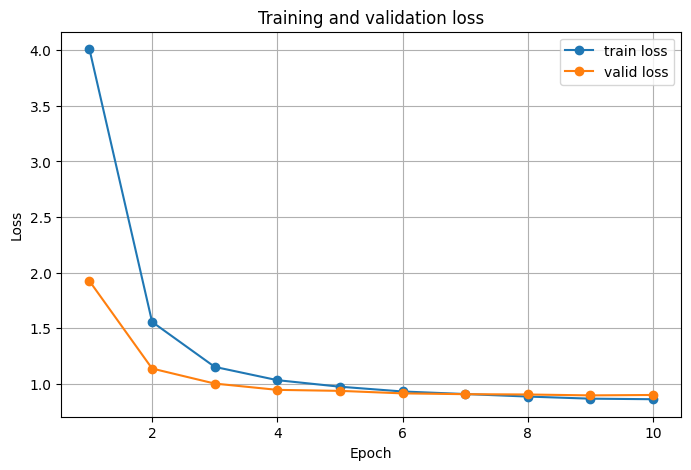

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="train loss",
)

plt.plot(
    history_df["epoch"],
    history_df["valid_loss"],
    marker="o",
    label="valid loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

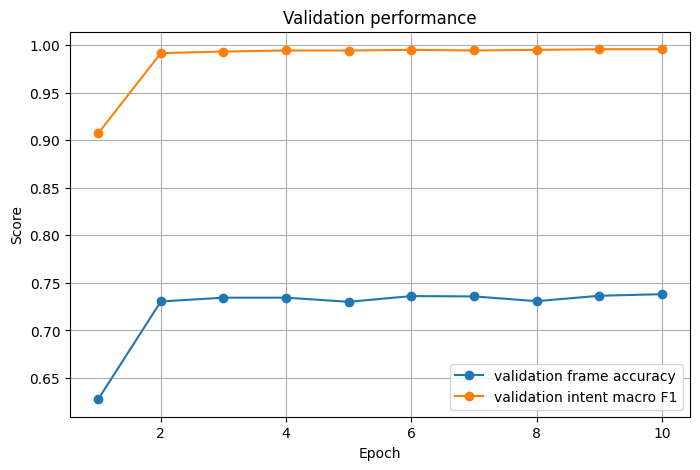

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["valid_frame_accuracy"],
    marker="o",
    label="validation frame accuracy",
)

plt.plot(
    history_df["epoch"],
    history_df["valid_intent_macro_f1"],
    marker="o",
    label="validation intent macro F1",
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation performance")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device,
    )
)

test_metrics = evaluate_model(
    model,
    test_loader,
)

print(json.dumps(
    test_metrics,
    ensure_ascii=False,
    indent=2,
))

{
  "loss": NaN,
  "intent_accuracy": 0.798227675528289,
  "intent_macro_f1": 0.7831546237993635,
  "menu_accuracy": 0.97,
  "menu_macro_f1": 0.9695158102766799,
  "temperature_accuracy": 0.415,
  "temperature_macro_f1": 0.37485711702201896,
  "quantity_accuracy": 0.715,
  "quantity_macro_f1": 0.3606398020501944,
  "frame_accuracy": 0.7068847989093388
}


In [25]:
history_df.to_csv(
    OUTPUT_DIR / "training_history.csv",
    index=False,
)

with open(
    OUTPUT_DIR / "test_metrics.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        test_metrics,
        f,
        ensure_ascii=False,
        indent=2,
    )

label_maps = {
    "intent": intent_encoder.classes_.tolist(),
    "menu": menu_encoder.classes_.tolist(),
    "temperature": temperature_encoder.classes_.tolist(),
    "quantity": quantity_encoder.classes_.tolist(),
}

with open(
    OUTPUT_DIR / "label_maps.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        label_maps,
        f,
        ensure_ascii=False,
        indent=2,
    )

tokenizer.save_pretrained(
    OUTPUT_DIR / "tokenizer"
)

config = {
    "model_name": MODEL_NAME,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_length": MAX_LENGTH,
    "best_validation_frame_accuracy": best_frame_accuracy,
}

with open(
    OUTPUT_DIR / "experiment_config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        config,
        f,
        ensure_ascii=False,
        indent=2,
    )

print("저장 완료:", OUTPUT_DIR)

저장 완료: /content/multitask_koelectra_small


In [26]:
!cd /content && zip -r multitask_koelectra_small.zip multitask_koelectra_small

  adding: multitask_koelectra_small/ (stored 0%)
  adding: multitask_koelectra_small/best_model.pt (deflated 7%)
  adding: multitask_koelectra_small/test_metrics.json (deflated 50%)
  adding: multitask_koelectra_small/training_history.csv (deflated 61%)
  adding: multitask_koelectra_small/label_maps.json (deflated 41%)
  adding: multitask_koelectra_small/experiment_config.json (deflated 28%)
  adding: multitask_koelectra_small/tokenizer/ (stored 0%)
  adding: multitask_koelectra_small/tokenizer/tokenizer_config.json (deflated 44%)
  adding: multitask_koelectra_small/tokenizer/tokenizer.json (deflated 70%)


In [27]:
from google.colab import files

files.download(
    "/content/multitask_koelectra_small.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>